# Cluster exploration

Visual sanity-check for `cluster_regions.py`. Reads `region_features.csv`
(per-region feature matrix) and `region_clusters.csv` (`region_id` →
`cluster`) and lets you see how the clusters differ on drought rate, hottest
month, temperature, 91-day precip, and the drought threshold.

Two main exits:
- The plotting cells (run from top to bottom) for the per-feature views.
- `cluster_summary(c)` for a one-cluster digest at the bottom.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

## Load + merge

Per region we get the 14 raw features plus the cluster id. We also derive two
extra columns used later:
- `mean_precip_91d ≈ annual_mean_precip × 91 / 365` — the typical 91-day total
- `precip_threshold = normalized_threshold × mean_precip_91d` — recovered approximate threshold
- `max_temp_month` and `max_precip_month` — decoded back from their sin/cos pair

In [2]:
feat = pd.read_csv('region_features.csv').set_index('region_id')
clu  = pd.read_csv('region_clusters.csv').set_index('region_id')
df = feat.join(clu)

def _month_from_sincos(s, c):
    angle = np.arctan2(s, c)
    angle = np.where(angle <= 0, angle + 2 * np.pi, angle)
    m = np.round(angle * 12 / (2 * np.pi)).astype(int)
    return np.where(m == 0, 12, m)

df['max_temp_month']   = _month_from_sincos(df['sin_max_temp_month'].values,
                                            df['cos_max_temp_month'].values)
df['max_precip_month'] = _month_from_sincos(df['sin_max_precip_month'].values,
                                            df['cos_max_precip_month'].values)
df['mean_precip_91d']  = df['annual_mean_precip'] * 91 / 365
df['precip_threshold'] = df['normalized_threshold'] * df['mean_precip_91d']

K = int(df['cluster'].max())
print(f'{len(df)} regions across {K} clusters')
df.head()

2248 regions across 22 clusters


,sin_max_temp_month,cos_max_temp_month,precip_drought_corr,drought_rate,normalized_threshold,annual_mean_precip,annual_temp_range,sin_max_precip_month,cos_max_precip_month,precip_seasonality,annual_mean_temp,temp_seasonality,mean_score_when_drought,aridity_index,cluster,max_temp_month,max_precip_month,mean_precip_91d,precip_threshold
region_id,,,,,,,,,,,,,,,,,,,
R1,-0.5,-0.866025,-0.568508,0.460630,0.866882,1441.663353,21.104839,-2.449294e-16,1.0,0.216926,17.643469,0.439030,1.658120,38.297834,12,7,12,359.428398,311.582004
R1001,-0.5,-0.866025,-0.566996,0.301181,0.737101,1257.674166,25.373774,8.660254e-01,-0.5,0.215563,14.515230,0.648792,2.026144,36.438238,11,7,4,313.557121,231.123394
R1002,-0.5,-0.866025,-0.477583,0.183071,0.613392,1437.946844,25.385226,8.660254e-01,-0.5,0.179937,13.664299,0.682897,1.666667,42.714296,9,7,4,358.501816,219.902018
R1005,-0.5,-0.866025,-0.463538,0.224409,0.804049,1337.664116,25.883355,8.660254e-01,-0.5,0.202641,13.467349,0.708466,1.763158,39.969228,9,7,4,333.499821,268.150264
R1006,-0.5,-0.866025,-0.477515,0.157480,0.612568,1356.593708,25.697032,8.660254e-01,-0.5,0.192046,13.336276,0.711913,1.650000,40.694219,9,7,4,338.219253,207.182225


## Cluster sizes

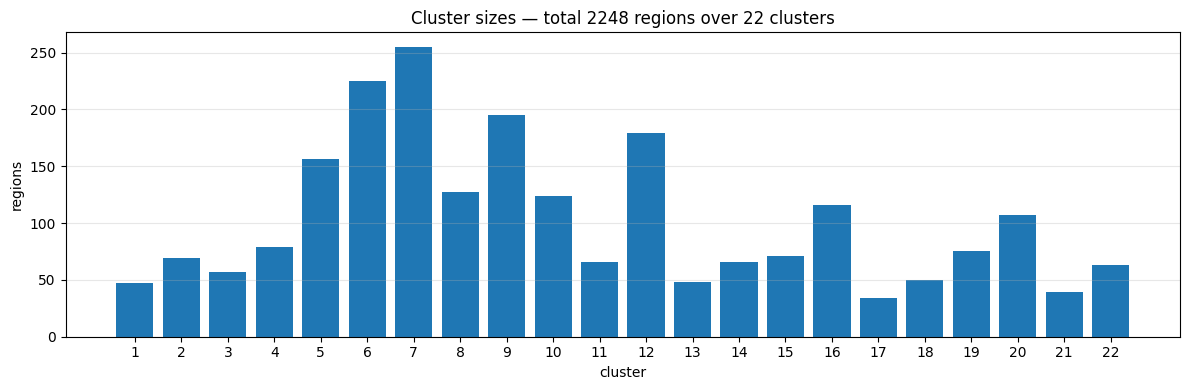

count     22.0
mean     102.2
std       63.3
min       34.0
25%       58.5
50%       73.0
75%      126.2
max      255.0


In [3]:
sizes = df['cluster'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(sizes.index, sizes.values, color='C0')
ax.set_xlabel('cluster')
ax.set_ylabel('regions')
ax.set_title(f'Cluster sizes — total {len(df)} regions over {K} clusters')
ax.set_xticks(sizes.index)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

print(sizes.describe().round(1).to_string())

## How much do average drought scores differ?

Two related views:
- `drought_rate` — fraction of weekly observations with score ≥ 1
- `mean_score_when_drought` — average severity *given* a drought is happening

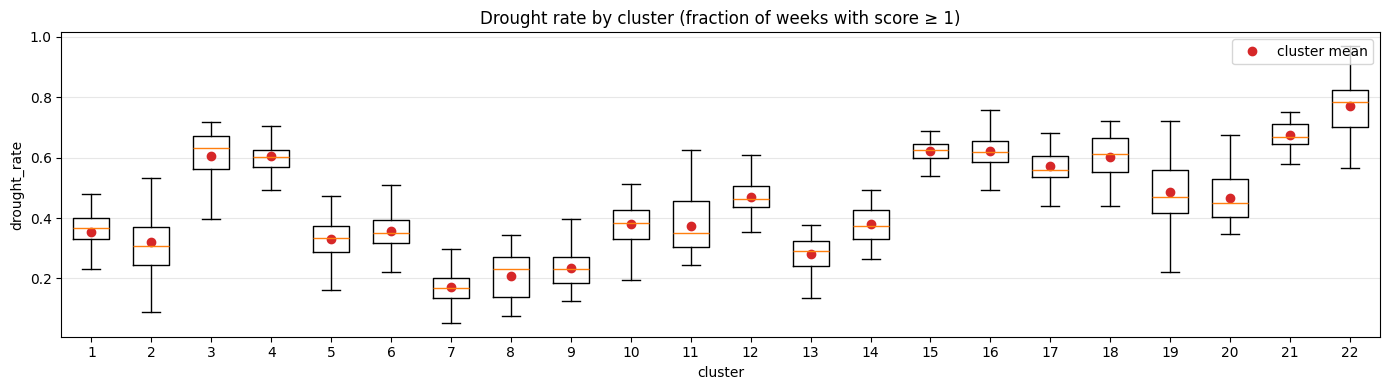

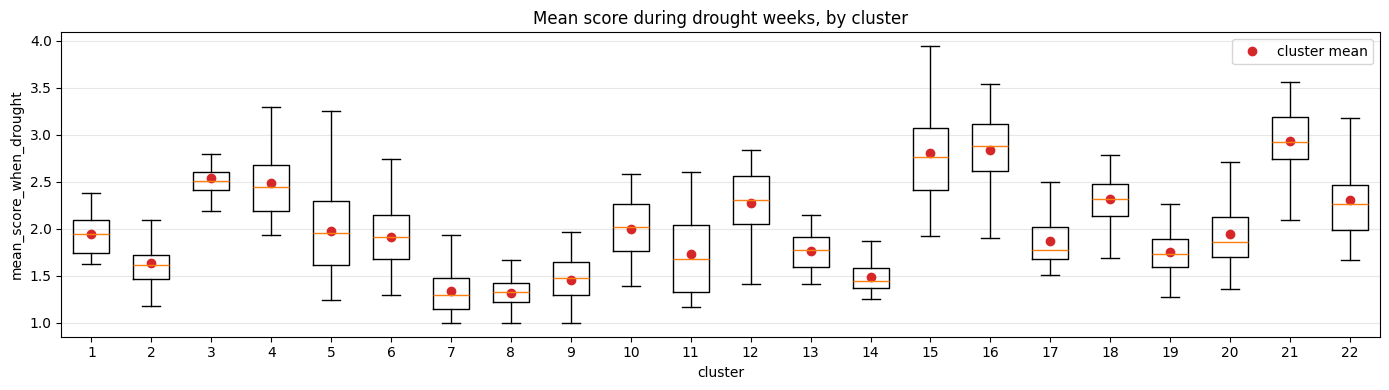

In [4]:
def _box_by_cluster(col, title, ylabel):
    fig, ax = plt.subplots(figsize=(14, 4))
    data = [df.loc[df['cluster'] == c, col].values for c in range(1, K + 1)]
    ax.boxplot(data, positions=range(1, K + 1), widths=0.6, showfliers=False)
    means = [np.mean(d) if len(d) else np.nan for d in data]
    ax.plot(range(1, K + 1), means, 'o', color='C3', label='cluster mean')
    ax.set_xlabel('cluster'); ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_xticks(range(1, K + 1))
    ax.grid(axis='y', alpha=0.3)
    ax.legend(loc='upper right')
    plt.tight_layout(); plt.show()

_box_by_cluster('drought_rate',
                'Drought rate by cluster (fraction of weeks with score ≥ 1)',
                'drought_rate')
_box_by_cluster('mean_score_when_drought',
                'Mean score during drought weeks, by cluster',
                'mean_score_when_drought')

### Cluster-mean drought summary table
Sorted by drought rate so the dry clusters bubble to the top.

In [5]:
summary = (df.groupby('cluster')
             .agg(size=('cluster', 'size'),
                  drought_rate=('drought_rate', 'mean'),
                  mean_score_when_drought=('mean_score_when_drought', 'mean'),
                  annual_mean_precip=('annual_mean_precip', 'mean'),
                  annual_mean_temp=('annual_mean_temp', 'mean'))
             .round(2)
             .sort_values('drought_rate', ascending=False))
summary

,size,drought_rate,mean_score_when_drought,annual_mean_precip,annual_mean_temp
cluster,,,,,
22,63,0.77,2.31,328.69,13.16
21,39,0.68,2.93,667.88,13.16
15,71,0.62,2.81,738.39,17.03
16,116,0.62,2.83,454.12,15.84
4,79,0.61,2.48,810.41,20.58
3,57,0.61,2.54,884.28,19.76
18,50,0.60,2.31,441.39,8.59
17,34,0.57,1.87,502.75,9.03
19,75,0.49,1.75,582.70,5.76


## Hottest month per cluster

Two views:
1. **Overall histogram** — what's the dominant hottest month across all regions.
2. **Cluster × month heatmap** — how regions inside each cluster distribute over months.

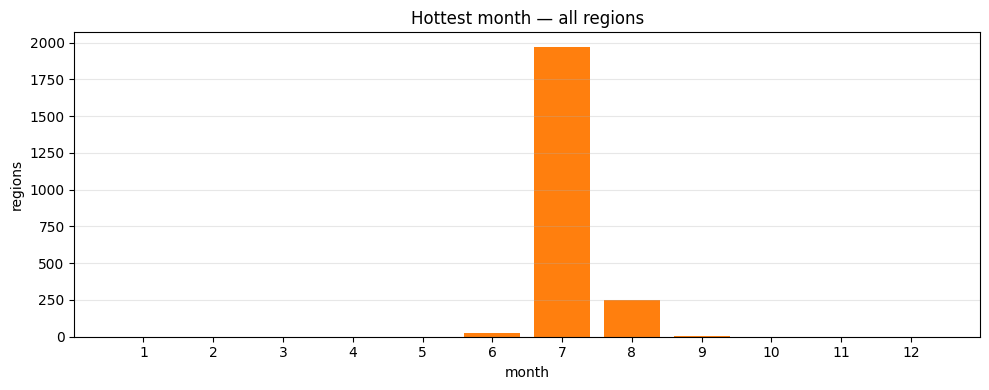

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
counts = df['max_temp_month'].value_counts().reindex(range(1, 13), fill_value=0)
ax.bar(counts.index, counts.values, color='C1')
ax.set_xlabel('month'); ax.set_ylabel('regions')
ax.set_title('Hottest month — all regions')
ax.set_xticks(range(1, 13))
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

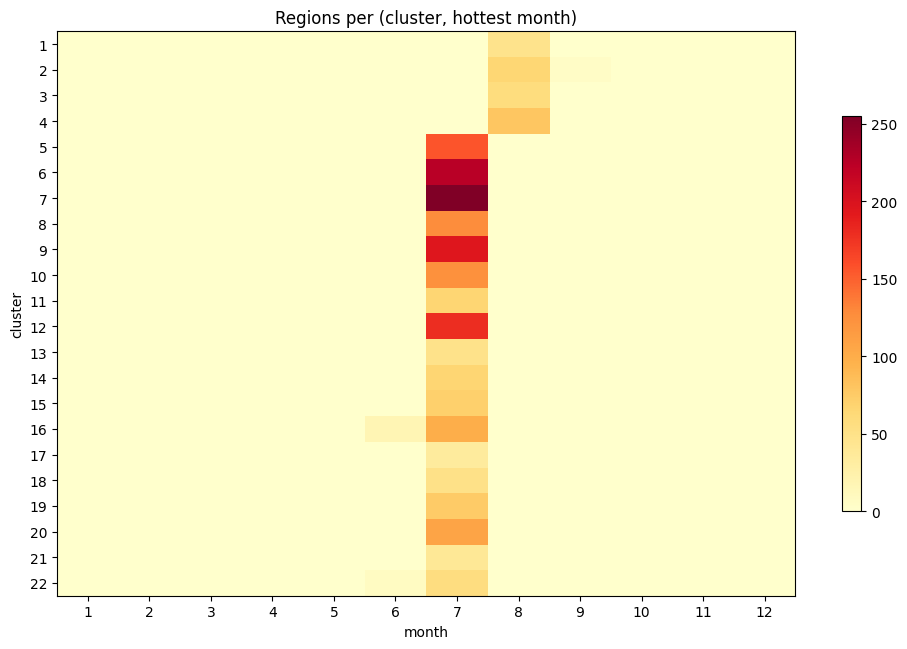

In [7]:
# Per-cluster heatmap: row=cluster, col=month, value=count
heat = (df.groupby(['cluster', 'max_temp_month'])
          .size().unstack(fill_value=0)
          .reindex(columns=range(1, 13), fill_value=0))

fig, ax = plt.subplots(figsize=(10, max(4, 0.3 * K)))
im = ax.imshow(heat.values, aspect='auto', cmap='YlOrRd')
ax.set_xticks(range(12)); ax.set_xticklabels(range(1, 13))
ax.set_yticks(range(K));  ax.set_yticklabels(heat.index)
ax.set_xlabel('month');   ax.set_ylabel('cluster')
ax.set_title('Regions per (cluster, hottest month)')
fig.colorbar(im, ax=ax, shrink=0.7)
plt.tight_layout(); plt.show()

## Annual mean temperature distribution

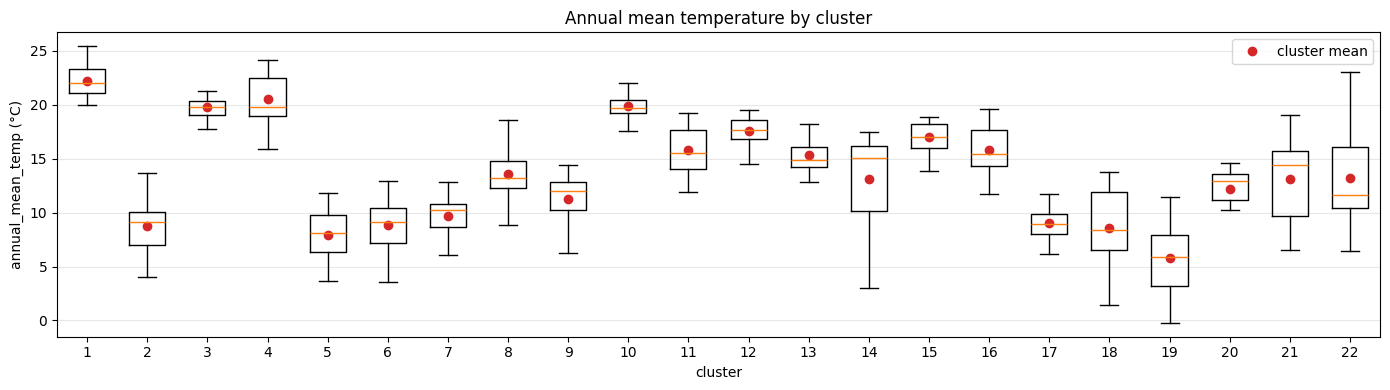

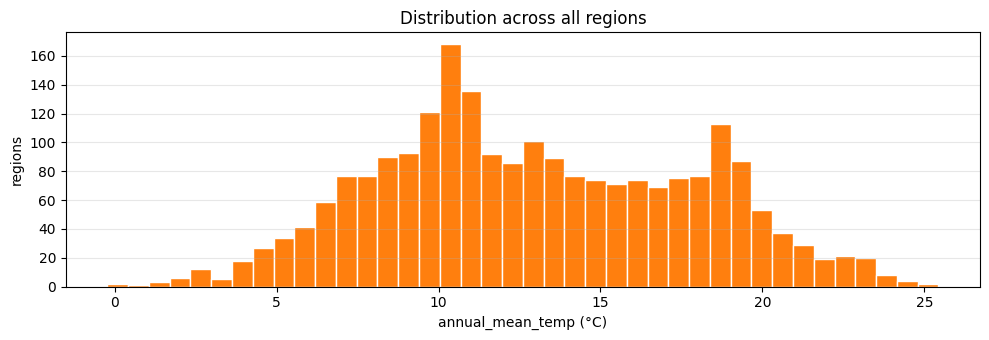

In [8]:
_box_by_cluster('annual_mean_temp',
                'Annual mean temperature by cluster',
                'annual_mean_temp (°C)')

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.hist(df['annual_mean_temp'], bins=40, color='C1', edgecolor='white')
ax.set_xlabel('annual_mean_temp (°C)'); ax.set_ylabel('regions')
ax.set_title('Distribution across all regions')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

## 91-day precipitation distribution

Per-region mean precip-91d, approximated as `annual_mean_precip × 91 / 365`.

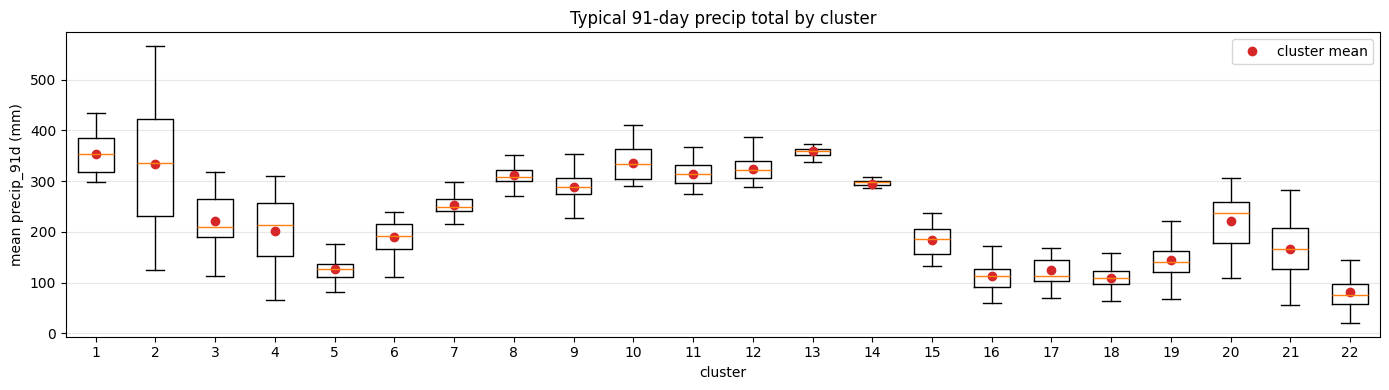

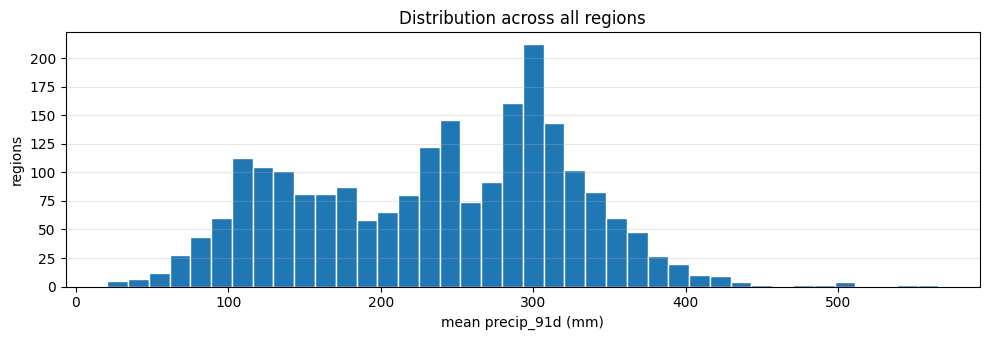

In [9]:
_box_by_cluster('mean_precip_91d',
                'Typical 91-day precip total by cluster',
                'mean precip_91d (mm)')

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.hist(df['mean_precip_91d'], bins=40, color='C0', edgecolor='white')
ax.set_xlabel('mean precip_91d (mm)'); ax.set_ylabel('regions')
ax.set_title('Distribution across all regions')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

## Precip threshold (recovered)

`precip_threshold ≈ normalized_threshold × mean_precip_91d`. Below this, the
per-region binary classifier flips a region into drought-predicted. Useful to
see: do dry clusters trigger drought at small absolute deficits, or only when
precip falls *way* below their (already small) normal?

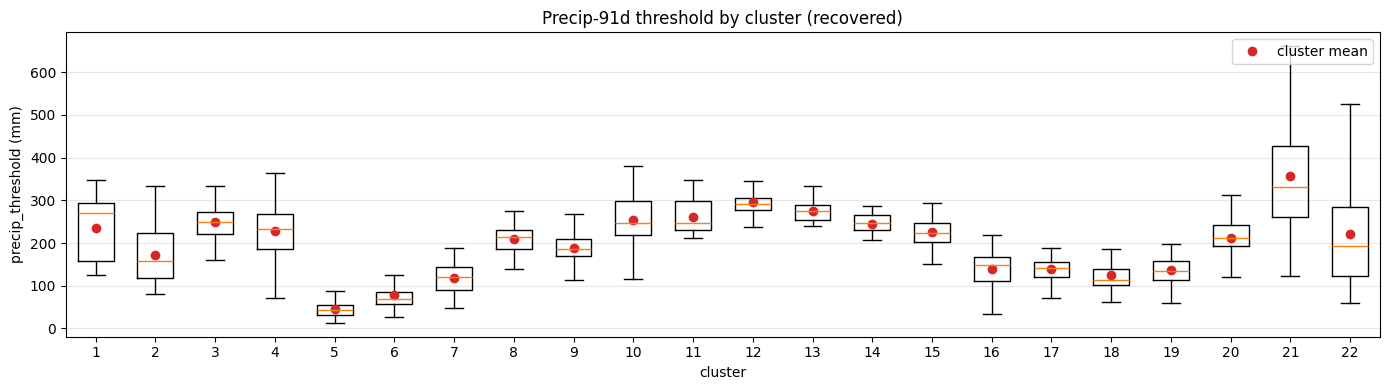

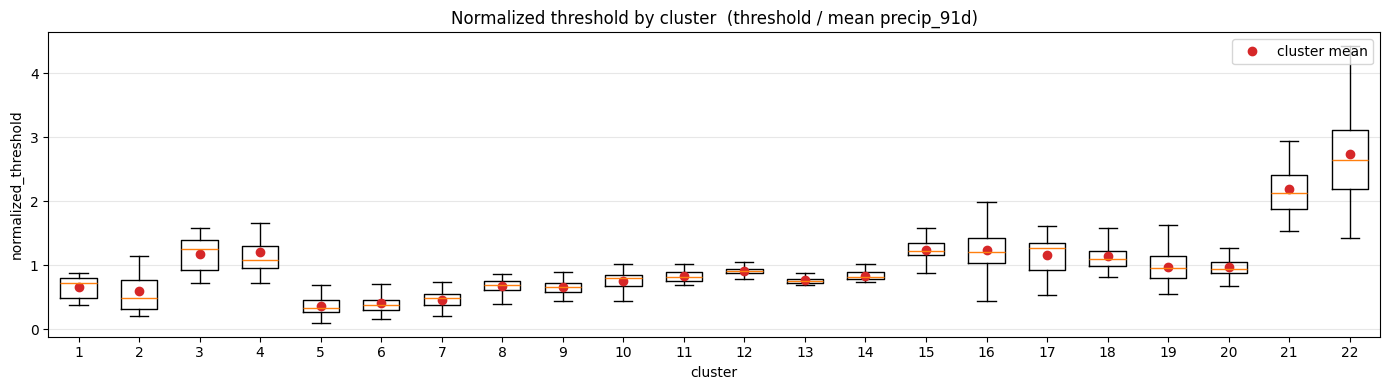

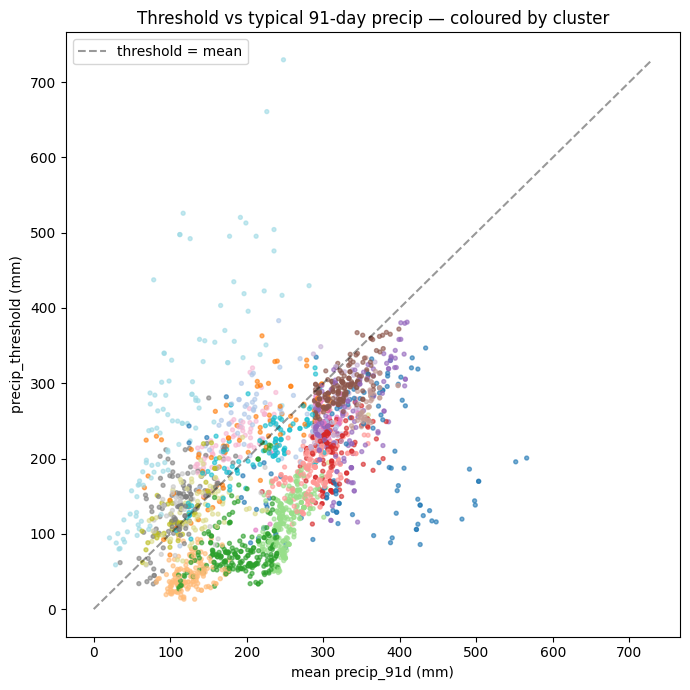

In [10]:
_box_by_cluster('precip_threshold',
                'Precip-91d threshold by cluster (recovered)',
                'precip_threshold (mm)')

# Also plot the normalized version — comparable across regions of any wetness
_box_by_cluster('normalized_threshold',
                'Normalized threshold by cluster  (threshold / mean precip_91d)',
                'normalized_threshold')

# Scatter: where does threshold sit relative to mean for each region?
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(df['mean_precip_91d'], df['precip_threshold'],
           c=df['cluster'], cmap='tab20', s=8, alpha=0.6)
lim = max(df['mean_precip_91d'].max(), df['precip_threshold'].max())
ax.plot([0, lim], [0, lim], 'k--', alpha=0.4, label='threshold = mean')
ax.set_xlabel('mean precip_91d (mm)')
ax.set_ylabel('precip_threshold (mm)')
ax.set_title('Threshold vs typical 91-day precip — coloured by cluster')
ax.legend(loc='upper left')
plt.tight_layout(); plt.show()

## One-cluster digest

`cluster_summary(c)` — printed cluster profile + the 14 features for its
regions. Useful for sanity-checking individual clusters.

In [11]:
def cluster_summary(c, n_show=5):
    sub = df[df['cluster'] == c]
    print(f'Cluster {c}  —  {len(sub)} regions')
    profile = sub.drop(columns=['cluster']).mean().round(2)
    print('Means:')
    print(profile.to_string())
    print(f'\nFirst {n_show} regions in this cluster:')
    display(sub.head(n_show))

cluster_summary(1)

Cluster 1  —  47 regions
Means:
sin_max_temp_month           -0.87
cos_max_temp_month           -0.50
precip_drought_corr          -0.54
drought_rate                  0.35
normalized_threshold          0.65
annual_mean_precip         1417.68
annual_temp_range            14.53
sin_max_precip_month         -0.73
cos_max_precip_month         -0.53
precip_seasonality            0.41
annual_mean_temp             22.23
temp_seasonality              0.24
mean_score_when_drought       1.94
aridity_index                33.67
max_temp_month                8.00
max_precip_month              7.77
mean_precip_91d             353.45
precip_threshold            234.34

First 5 regions in this cluster:


,sin_max_temp_month,cos_max_temp_month,precip_drought_corr,drought_rate,normalized_threshold,annual_mean_precip,annual_temp_range,sin_max_precip_month,cos_max_precip_month,precip_seasonality,annual_mean_temp,temp_seasonality,mean_score_when_drought,aridity_index,cluster,max_temp_month,max_precip_month,mean_precip_91d,precip_threshold
region_id,,,,,,,,,,,,,,,,,,,
R1083,-0.866025,-0.5,-0.534160,0.387795,0.768651,1498.069074,17.312806,-0.866025,-0.5,0.291409,20.997360,0.303349,1.639594,36.540623,1,8,8,373.491194,287.084224
R1089,-0.866025,-0.5,-0.576565,0.409449,0.851611,1555.582948,18.623161,-0.866025,-0.5,0.181365,20.304641,0.338619,2.206731,38.595628,1,8,8,387.830269,330.280538
R1091,-0.866025,-0.5,-0.542127,0.411417,0.752700,1699.209609,17.346839,-0.866025,-0.5,0.227451,21.399740,0.297069,2.043062,41.043968,1,8,8,423.638560,318.872806
R1102,-0.866025,-0.5,-0.481360,0.346457,0.801762,1669.599556,17.298645,-0.866025,-0.5,0.292743,21.065397,0.302117,1.625000,40.657090,1,8,8,416.256328,333.738511
R1105,-0.866025,-0.5,-0.636791,0.379921,0.769617,1515.041398,16.897194,-0.866025,-0.5,0.294767,21.327634,0.291683,1.658031,36.659282,1,8,8,377.722650,290.701644
